# This notebook calculates monomer-monomer interaction energy

In [3]:
# Import modules

import numpy as np
import matplotlib.pyplot as plt
from scipy.constants import Boltzmann
from pathlib import Path
from itertools import count
p = Path('.')
from Dfit import *
from matplotlib.ticker import MultipleLocator
import pandas as pd
from scipy.stats import kde
from sklearn.neighbors import KernelDensity

/home/pallab/Softwares/anaconda3/envs/MDAna/lib/python3.10/site-packages/pandas/core/computation/expressions.py:21: UserWarning: Pandas requires version '2.8.4' or newer of 'numexpr' (version '2.7.3' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED


# Analysis

In [4]:
def FormatPlot(ax):
    for axis in ['top','bottom','left','right']:
        ax.spines[axis].set_linewidth(2)
    ax.xaxis.set_tick_params(width=2,length=8,direction='in',labelsize=16)
    ax.yaxis.set_tick_params(width=2,length=8,direction='in',labelsize=16)
    ax.xaxis.set_tick_params(which='minor',width=2,length=4,direction='in')
    ax.yaxis.set_tick_params(which='minor',width=2,length=4,direction='in')
    for label in ax.get_xticklabels():
        label.set_fontweight('bold')
    
    # 2. Get the tick labels for the Y-axis and set their font weight
    for label in ax.get_yticklabels():
        label.set_fontweight('bold')
    ax.grid(which='major',color='silver',linestyle='dashed')
    ax.grid(which='minor',color='silver',linestyle='dotted',alpha=0.5)

In [5]:
def myPlotDistIntE(file1, file2, ax, COLOR, tickl=True, tickr=True, tickb=False, title="", Label="", lstyle='solid'):
    """This plots Dist-bw-Interface-COM and Interaction Energy using 2 Y-axis"""
    r1 = np.loadtxt(file1, skiprows=24)
    r2 = np.loadtxt(file2, skiprows=24)
    df1 = pd.DataFrame(r1)
    df2 = pd.DataFrame(r2)
    r_y2 = ((df1[1]+df2[1])*0.239).rolling(window=1000).mean()
    ax.plot(df2[0]/1e3,r_y2,color=COLOR,label=Label,lw=2,ls=lstyle)
    ax.set_ylim(-100,5) # for TPP3
    if tickr:
        ax.set_ylabel(r"$\bf{E_{Int}\;(kcal\,mol^{-1})}$",color="k",fontsize=16)
        ax.set_xlabel(r"$\bf{time\;(ns)}$",color="k",fontsize=16)
    ax.tick_params(axis='y', colors='k', width=2, length=5)

# Figures

## Fig 1A

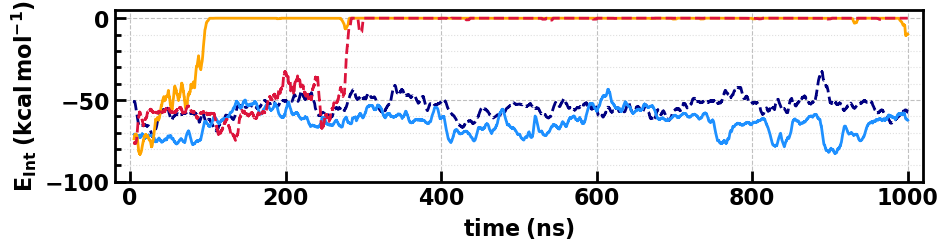

In [6]:
%matplotlib inline

fig, ax = plt.subplots(1,1,figsize=(2.4*4,2.6),sharex=True)

myPlotDistIntE('Coul-tpp3-220K-interface.xvg','LJ-tpp3-220K-interface.xvg',ax,'navy',tickl=True,Label='220K',lstyle='dashed')
myPlotDistIntE('Coul-tpp3-p310s220-interface.xvg','LJ-tpp3-p310s220-interface.xvg',ax,'dodgerblue',tickr=True,Label='p310s220')
myPlotDistIntE('Coul-tpp3-p220s310-interface.xvg','LJ-tpp3-p220s310-interface.xvg',ax,'orange',tickl=True,tickb=True,Label='p220s310')
myPlotDistIntE('Coul-tpp3-310K-interface.xvg','LJ-tpp3-310K-interface.xvg',ax,'crimson',tickr=True,tickb=True,Label='310K',lstyle='dashed')

ax.yaxis.set_minor_locator(MultipleLocator(10))
ax.xaxis.set_minor_locator(MultipleLocator(1000))
#plt.xlim(-0.02,1.02)
plt.xlim(-20,1020)
FormatPlot(ax)

#plt.legend()
plt.tight_layout()
#plt.savefig("Dist_and_IntEnergy_Rep5.png",dpi=300)